In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

file_path = '/Users/erhanali/Desktop/ITSS4381/WHO-COVID-19-global-data (1).csv'
covid_data = pd.read_csv(file_path)

covid_data_cleaned = covid_data.dropna(subset=['New_cases', 'New_deaths'])
covid_data_cleaned['Date_reported'] = pd.to_datetime(covid_data_cleaned['Date_reported'])


/var/folders/lf/2vf33h4x5y7gddzdt6_qqlsw0000gn/T/ipykernel_16414/2512274945.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid_data_cleaned['Date_reported'] = pd.to_datetime(covid_data_cleaned['Date_reported'])


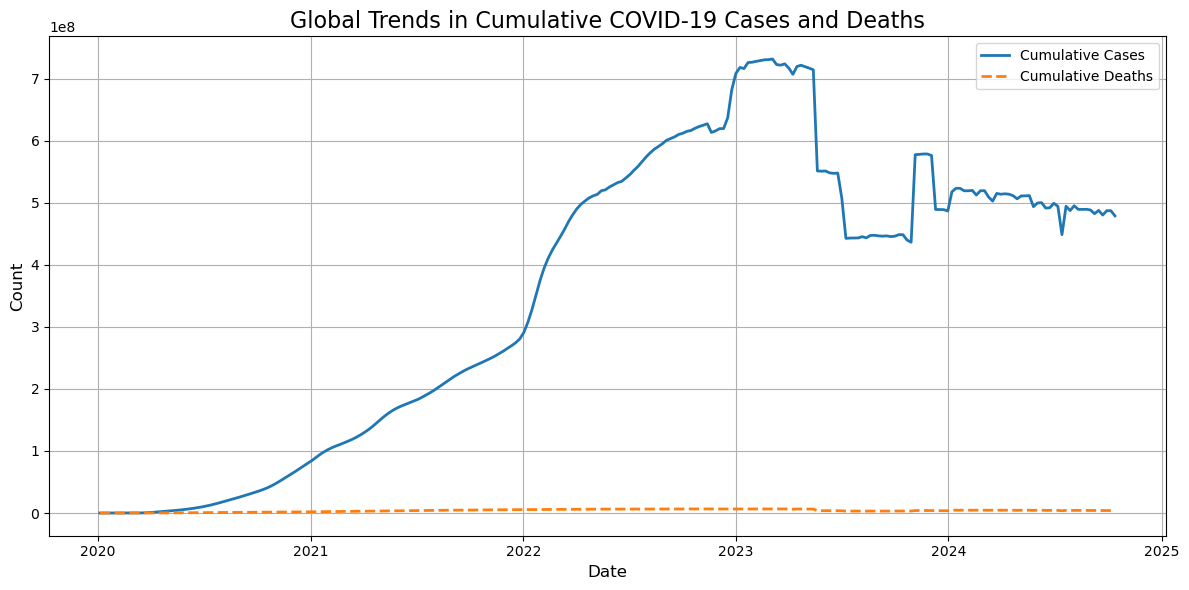

In [13]:

global_data = covid_data_cleaned.groupby('Date_reported').sum()
plt.figure(figsize=(12, 6))
plt.plot(global_data.index, global_data['Cumulative_cases'], label='Cumulative Cases', linewidth=2)
plt.plot(global_data.index, global_data['Cumulative_deaths'], label='Cumulative Deaths', linewidth=2, linestyle='--')
plt.title('Global Trends in Cumulative COVID-19 Cases and Deaths', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



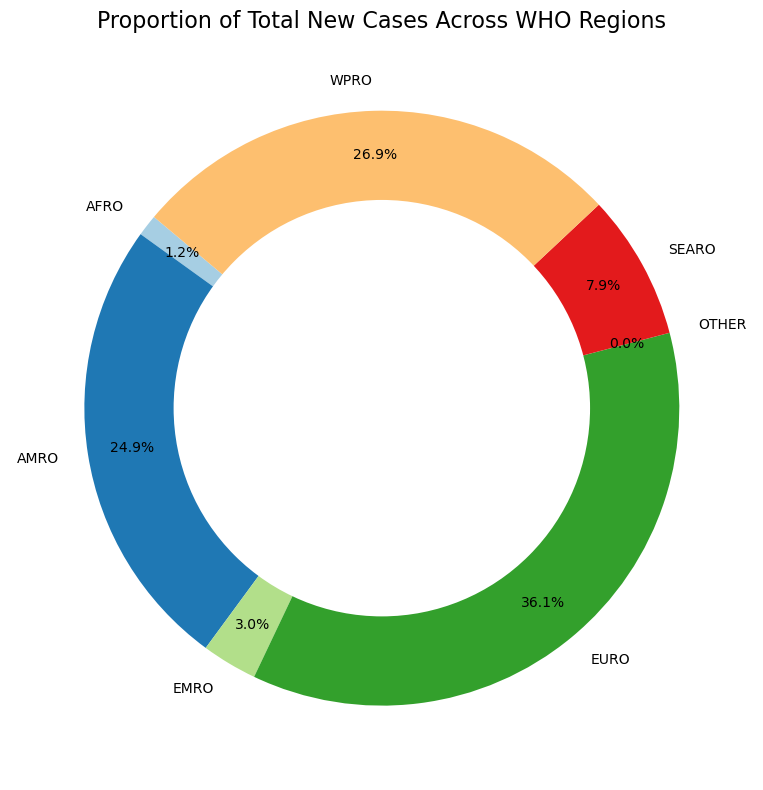

In [17]:
regional_data = covid_data_cleaned.groupby('WHO_region')[['New_cases', 'New_deaths']].sum()

labels = regional_data.index
sizes = regional_data['New_cases']
colors = plt.cm.Paired(range(len(labels)))  # Color palette

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Proportion of Total New Cases Across WHO Regions', fontsize=16)
plt.tight_layout()
plt.show()

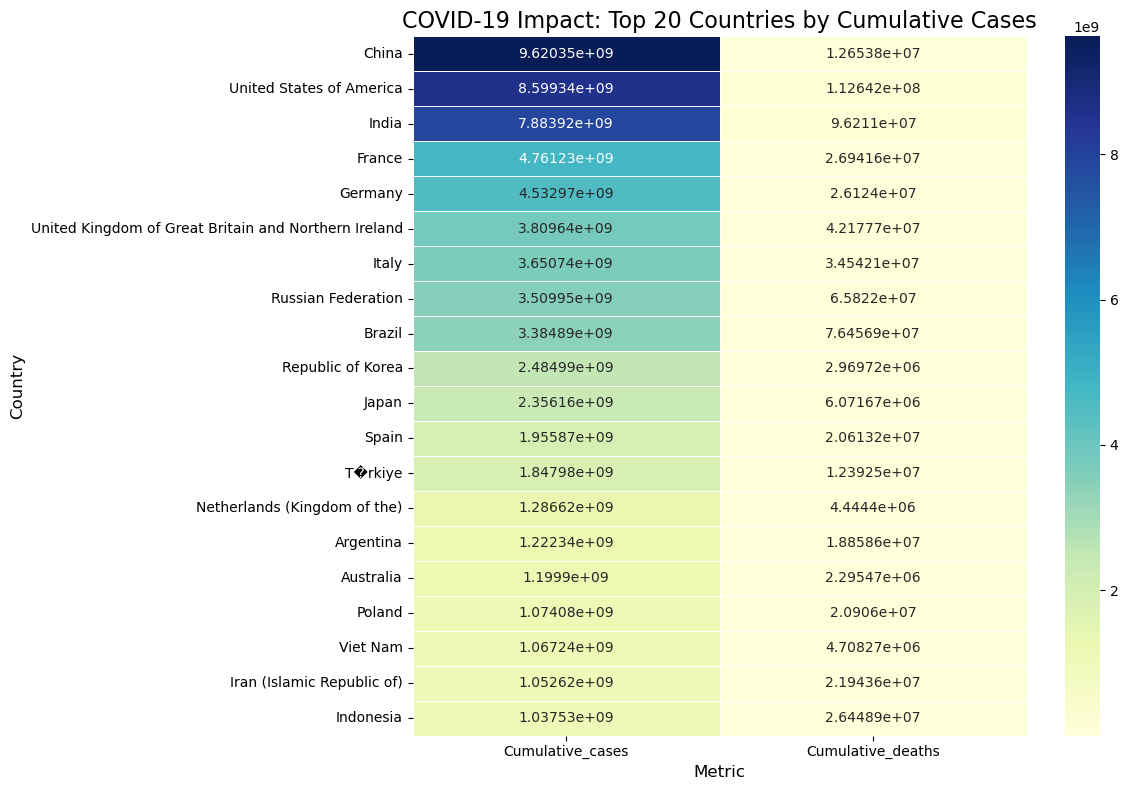

In [16]:
country_data = covid_data_cleaned.groupby('Country')[['Cumulative_cases', 'Cumulative_deaths']].sum()

top_countries = country_data.sort_values('Cumulative_cases', ascending=False).head(20)
heatmap_data = top_countries[['Cumulative_cases', 'Cumulative_deaths']]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt="g", cmap="YlGnBu", linewidths=0.5)
plt.title('COVID-19 Impact: Top 20 Countries by Cumulative Cases', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()


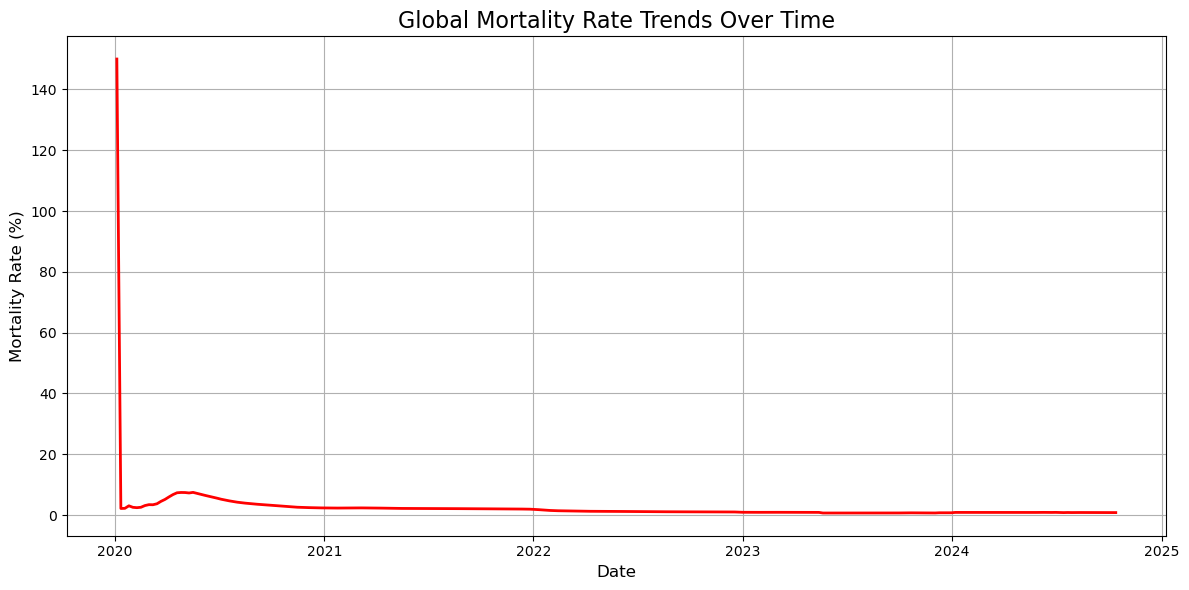

In [15]:
global_data['Mortality_rate'] = (global_data['Cumulative_deaths'] / global_data['Cumulative_cases']) * 100

global_data['Mortality_rate'] = global_data['Mortality_rate'].fillna(0)

plt.figure(figsize=(12, 6))
plt.plot(global_data.index, global_data['Mortality_rate'], color='red', linewidth=2)
plt.title('Global Mortality Rate Trends Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Mortality Rate (%)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()